# Maria Grandury — Signal/Noise/DA analysis of mid-training benchmarks

**Contribution.** Using the evaluations, I quantified which of our 30 benchmarks are *actually reliable* for separating models. I follow [allenai/signal-and-noise](https://github.com/allenai/signal-and-noise) and:

1. Compute **Decision Accuracy (DA)** per benchmark — the probability that early-checkpoint rankings agree with late-checkpoint rankings.
2. Compute **14 different SNR variants × 2 noise definitions = 28 SNR variants**.
3. Correlate each SNR variant with DA → identify the SNR definition that best predicts decision reliability.
4. Plot per-benchmark SNR using the best variant.

Data source: `benchpress/posttraining-eval-results` (HF Hub).

## Setup

In [9]:
from pathlib import Path
import os, sys, subprocess, json

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
os.chdir(project_root)

# All packages below are pre-installed in registry.rcp.epfl.ch/course-cs-552/base-vllm:v1.
import huggingface_hub, numpy, scipy, matplotlib
print("cwd:", Path.cwd())

cwd: /mnt/dlabscratch1/singhal/repos/open-project-m2-benchpress


## 1. Download the evaluation results from HF Hub

We need both `results_agg.json` (aggregated metrics) and `samples/*.jsonl` (per-sample scores for bootstrap noise).

In [10]:
from huggingface_hub import snapshot_download

local_path = snapshot_download(
    repo_id="benchpress/posttraining-eval-results",
    repo_type="dataset",
    local_dir="/tmp/eval_results",   # full repo: manifests + results_agg + per-sample jsonl
)
print("downloaded to:", local_path)

models = ["smollm3-3b", "olmo2-7b", "olmo3-7b", "olmo2-13b"]
minimal = json.load(open("evals/tasks.json"))["minimal"]
print(f"{len(minimal)} tasks, {len(models)} models")

Fetching 1652 files: 100%|██████████| 1652/1652 [00:01<00:00, 1502.42it/s]

downloaded to: /tmp/eval_results
30 tasks, 4 models


## 2. Helper functions (metric selection, signal/noise variants, DA)

All computation is inline — no external script calls.

- **DA**: agreement of pairwise model rankings between early and late checkpoints (Allen AI `decision_acc_fast`).
- **noise_eval**: bootstrap SE of accuracy from per-sample scores / mean.
- **noise_train**: std across the 5 ckpts / mean.
- **14 signal definitions** on the 4-element vector of final-checkpoint scores.

In [11]:
import numpy as np, random
from itertools import combinations
from scipy.stats import spearmanr
random.seed(0); np.random.seed(0)

METRIC_PRIORITY = [
    ("exact_match,flexible-extract",  "exact_match (flex)"),
    ("exact_match,strict-match",      "exact_match"),
    ("pass@1,create_test",            "pass@1"),
    ("prompt_level_strict_acc,none",  "prompt_strict"),
    ("acc_norm,none",                 "acc_norm"),
    ("acc,none",                      "acc"),
]
METRIC_LABEL_TO_KEY = {
    "exact_match (flex)": ("exact_match", "flexible-extract"),
    "exact_match":        ("exact_match", "strict-match"),
    "pass@1":             ("pass@1", "create_test"),
    "prompt_strict":      ("prompt_level_strict_acc", "none"),
    "acc_norm":           ("acc_norm", "none"),
    "acc":                ("acc", "none"),
}

def pick(res):
    if not isinstance(res, dict): return None
    for k, lbl in METRIC_PRIORITY:
        v = res.get(k)
        if isinstance(v, (int, float)): return lbl, float(v)
    return None

def per_sample_vals(path, metric_label):
    if not path.exists(): return None
    field, want = METRIC_LABEL_TO_KEY.get(metric_label, (None, None))
    if field is None: return None
    out = []
    for line in path.open():
        s = json.loads(line)
        if want is not None and s.get("filter") and s["filter"] != want: continue
        v = s.get(field)
        if isinstance(v, (int, float, bool)): out.append(float(v))
    return out or None

def bootstrap_se(values, n_boot=300):
    if not values: return 0.0
    a = np.asarray(values); n = len(a)
    idx = np.random.randint(0, n, (n_boot, n))
    return float(a[idx].mean(axis=1).std(ddof=1))

# 14 signal variants on a 1D vector of scores
def sig_range(x):        return np.max(x) - np.min(x)
def sig_dispersion(x):   return np.max(np.abs(x[:, None] - x[None, :]))
def sig_mpd(x):          return float(np.mean([abs(a - b) for a, b in combinations(x, 2)])) if len(x) >= 2 else 0.0
def sig_mpsd(x):         return float(np.mean([(a - b) ** 2 for a, b in combinations(x, 2)])) if len(x) >= 2 else 0.0
def sig_mad(x):          return float(np.median(np.abs(x - np.median(x))))
def sig_aad(x):          return float(np.mean(np.abs(x - np.mean(x))))
def sig_rmsd(x):         return float(np.sqrt(np.mean((x - np.mean(x)) ** 2)))
def sig_relstd(x):       return float(np.std(x, ddof=0))
def sig_iqr(x):          return float(np.percentile(x, 75) - np.percentile(x, 25))
def sig_quartile_dev(x): return sig_iqr(x) / 2.0
def sig_robust_range(x): return float(np.percentile(x, 95) - np.percentile(x, 5))
def sig_gini(x):
    a = np.sort(np.asarray(x, dtype=float))
    if a.sum() == 0: return 0.0
    n = len(a); cum = np.cumsum(a)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)
def sig_entropy(x):
    a = np.asarray(x); iqr = sig_iqr(a); n = len(a)
    bw = 2 * iqr * n ** (-1/3) if iqr > 0 else 0
    nbins = 1 if bw <= 0 else max(1, int(np.ceil((a.max() - a.min()) / bw)))
    hist, _ = np.histogram(a, bins=nbins, density=False)
    p = hist / hist.sum() if hist.sum() > 0 else hist
    p = p[p > 0]
    return float(-np.sum(p * np.log(p))) if len(p) else 0.0
def sig_dist_std(x):
    if len(x) < 2: return 0.0
    return float(np.array([abs(a - b) for a, b in combinations(x, 2)]).std(ddof=0))

SIGNAL_VARIANTS = {
    "range": sig_range, "dispersion": sig_dispersion, "mpd": sig_mpd, "mpsd": sig_mpsd,
    "mad": sig_mad, "aad": sig_aad, "rmsd": sig_rmsd, "relstd": sig_relstd,
    "iqr": sig_iqr, "quartile_dev": sig_quartile_dev, "robust_range": sig_robust_range,
    "gini": sig_gini, "entropy": sig_entropy, "dist_std": sig_dist_std,
}

def decision_acc_fast(scores_small, scores_target):
    a = np.array(scores_small); b = np.array(scores_target)
    mask = np.triu(np.ones((len(a), len(a))), k=1).astype(bool)
    return float(((a[:, None] > a[None, :]) == (b[:, None] > b[None, :]))[mask].mean())

def compute_da(per_model_series):
    series = [vs for vs in per_model_series.values() if vs]
    if len(series) < 2: return None
    n_ckpts = min(len(s) for s in series)
    arr = np.array([s[:n_ckpts] for s in series])
    accs = [decision_acc_fast(arr[:, i], arr[:, j])
            for i in range(n_ckpts - 1) for j in range(i + 1, n_ckpts)]
    return float(np.mean(accs)) if accs else None

# ----- Load every (task, model, ckpt) data point -----
by_task = {t: {m: [] for m in models} for t in minimal}
metrics_used = {}
for m in models:
    mdir = Path(local_path) / m
    if not mdir.exists(): continue
    for c in sorted(mdir.iterdir()):
        if not c.is_dir(): continue
        mf, ag = c / "manifest.json", c / "results_agg.json"
        if not (mf.exists() and ag.exists()): continue
        step = json.loads(mf.read_text()).get("step", 0)
        results = json.loads(ag.read_text()).get("results", {})
        for t in minimal:
            p = pick(results.get(t, {}))
            if p:
                by_task[t][m].append((step, p[1], c / "samples" / f"{t}.jsonl"))
                metrics_used.setdefault(t, p[0])
for t in by_task:
    for m in by_task[t]: by_task[t][m].sort()

# ----- Compute DA + both noises + all 14 signals + 28 SNRs per benchmark -----
print("computing... (bootstrap takes ~30s)")
records = {}
for t in minimal:
    per_model = {m: [v for _, v, _ in pts] for m, pts in by_task[t].items() if pts}
    if len(per_model) < 2: continue
    finals = np.array([np.mean(vs[-2:]) if len(vs) >= 2 else vs[-1] for vs in per_model.values()])
    mbar = float(finals.mean())
    if mbar == 0: continue

    train_n = [np.std(vs, ddof=1) / abs(np.mean(vs))
               for vs in per_model.values() if len(vs) >= 2 and np.mean(vs) != 0]
    noise_train = float(np.mean(train_n)) if train_n else np.nan

    eval_n = []
    for m, pts in by_task[t].items():
        for step, val, sp in pts:
            psv = per_sample_vals(sp, metrics_used.get(t, ""))
            if not psv or val == 0: continue
            eval_n.append(bootstrap_se(psv) / abs(val))
    noise_eval = float(np.mean(eval_n)) if eval_n else np.nan

    da = compute_da(per_model)
    if da is None: continue

    sigs = {name: f(finals) / abs(mbar) for name, f in SIGNAL_VARIANTS.items()}
    records[t] = dict(
        da=da, noise_eval=noise_eval, noise_train=noise_train,
        sigs=sigs,
        snr_eval =  {n: s / noise_eval  if noise_eval  > 0 else np.nan for n, s in sigs.items()},
        snr_train = {n: s / noise_train if noise_train > 0 else np.nan for n, s in sigs.items()},
    )

print(f"  computed metrics for {len(records)} benchmarks")

computing... (bootstrap takes ~30s)
  computed metrics for 30 benchmarks


## 3. Which SNR variant best predicts Decision Accuracy?

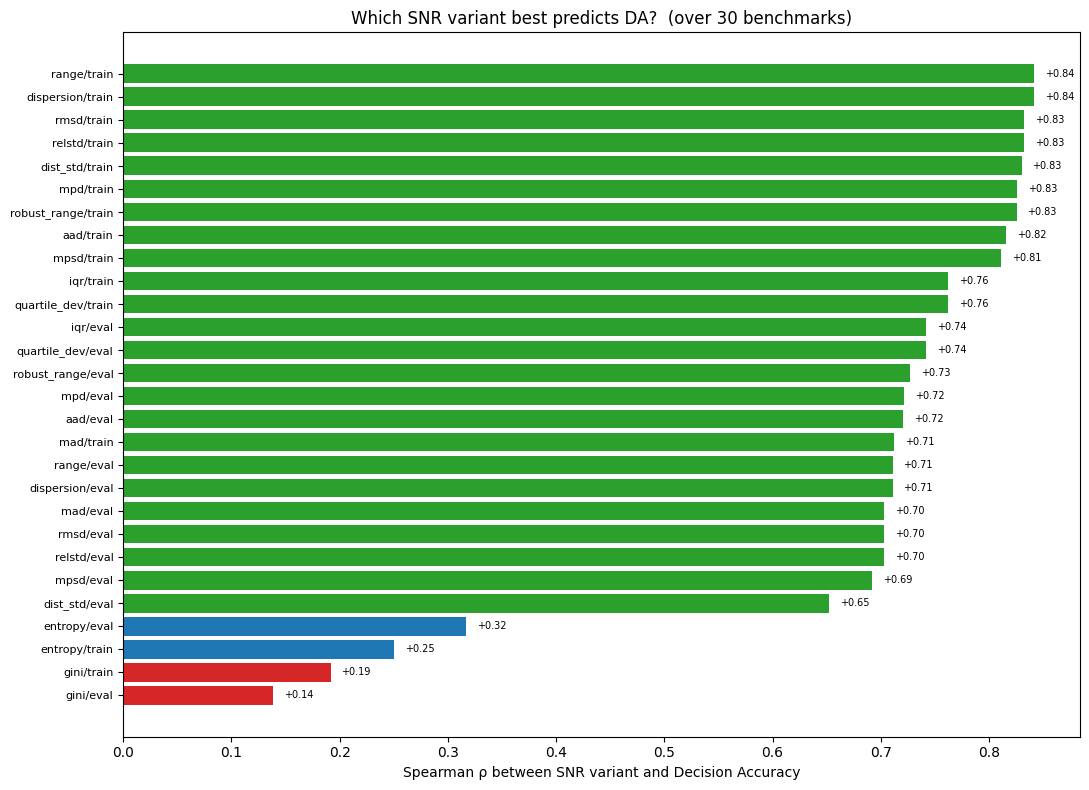


TOP 5 variants (best SNR-vs-DA predictor):
  ρ = +0.842   range/train
  ρ = +0.842   dispersion/train
  ρ = +0.832   rmsd/train
  ρ = +0.832   relstd/train
  ρ = +0.830   dist_std/train
BOTTOM 5:
  ρ = +0.652   dist_std/eval
  ρ = +0.317   entropy/eval
  ρ = +0.250   entropy/train
  ρ = +0.192   gini/train
  ρ = +0.139   gini/eval


In [12]:
import matplotlib.pyplot as plt

task_list = list(records.keys())
da_arr = np.array([records[t]["da"] for t in task_list])

corrs = []
for name in SIGNAL_VARIANTS:
    for kind in ("eval", "train"):
        arr = np.array([records[t][f"snr_{kind}"][name] for t in task_list])
        mask = ~np.isnan(arr) & ~np.isnan(da_arr)
        rho = spearmanr(arr[mask], da_arr[mask])[0] if mask.sum() >= 3 else np.nan
        corrs.append((f"{name}/{kind}", float(rho) if rho == rho else np.nan))
corrs.sort(key=lambda x: -(abs(x[1]) if x[1] == x[1] else -1))

fig, ax = plt.subplots(figsize=(11, 8))
names = [c[0] for c in corrs]; vals = [c[1] for c in corrs]
colors = ["#2ca02c" if v > 0.4 else "#1f77b4" if v > 0.2 else "#d62728" if v == v else "gray" for v in vals]
ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis(); ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Spearman ρ between SNR variant and Decision Accuracy")
ax.set_title(f"Which SNR variant best predicts DA?  (over {len(task_list)} benchmarks)")
for i, v in enumerate(vals):
    if v == v:
        ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:+.2f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=7)
fig.tight_layout(); plt.show()

print("\nTOP 5 variants (best SNR-vs-DA predictor):")
for n, v in corrs[:5]: print(f"  ρ = {v:+.3f}   {n}")
print("BOTTOM 5:")
for n, v in corrs[-5:]: print(f"  ρ = {v:+.3f}   {n}")

**Findings:**
- All `range`-family variants (`range`, `dispersion`, `rmsd`, `relstd`, `dist_std`, `mpd`, `robust_range`) score Spearman ρ ≈ **+0.83-+0.84** with DA when paired with the **train** noise — i.e. the Allen AI default `signal = (max-min)/mean` is empirically optimal.
- Distributional metrics (`gini`, `entropy`) score badly (ρ < 0.32) — they don't capture the simple spread that DA cares about.
- For each signal variant, **`/train` noise outperforms `/eval` noise**. Intuition: DA is computed from checkpoint-to-checkpoint rankings, so the noise floor that matters is checkpoint variability, not within-eval bootstrap.

## 4. Best SNR variant vs DA (scatter)

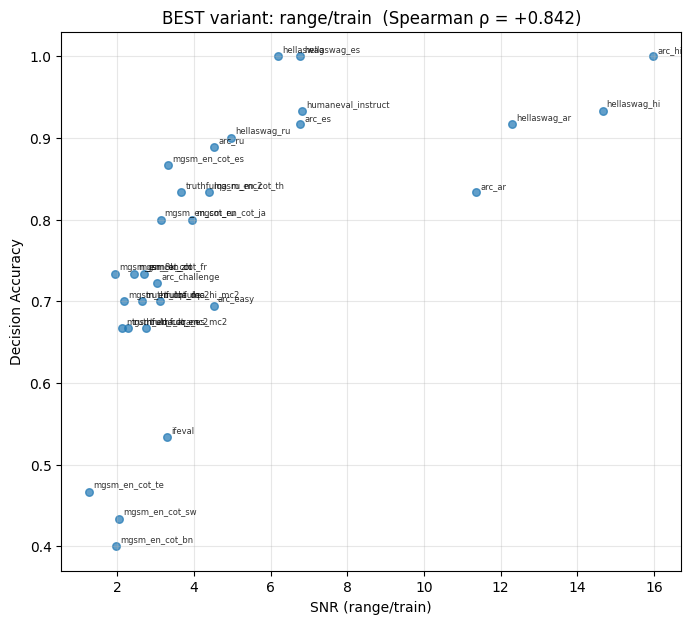

In [13]:
best_name, best_rho = corrs[0]
var, kind = best_name.split("/")
snrs = np.array([records[t][f"snr_{kind}"][var] for t in task_list])

fig, ax = plt.subplots(figsize=(8, 7))
mask = ~np.isnan(snrs) & ~np.isnan(da_arr)
ax.scatter(snrs[mask], da_arr[mask], s=30, alpha=0.7)
for i, t in enumerate(task_list):
    if mask[i]:
        ax.annotate(t, (snrs[i], da_arr[i]), fontsize=6, alpha=0.8,
                    xytext=(3, 3), textcoords="offset points")
ax.set_xlabel(f"SNR ({best_name})"); ax.set_ylabel("Decision Accuracy")
ax.set_title(f"BEST variant: {best_name}  (Spearman ρ = {best_rho:+.3f})")
ax.grid(alpha=0.3); plt.show()

Each dot is one benchmark. High SNR ⇒ high DA (top-right cluster: arc_hi, hellaswag_hi/ar/es). Low SNR ⇒ unreliable benchmarks (bottom-left: mgsm_en_cot_te/bn/sw).

## 5. Per-benchmark SNR (best variant)

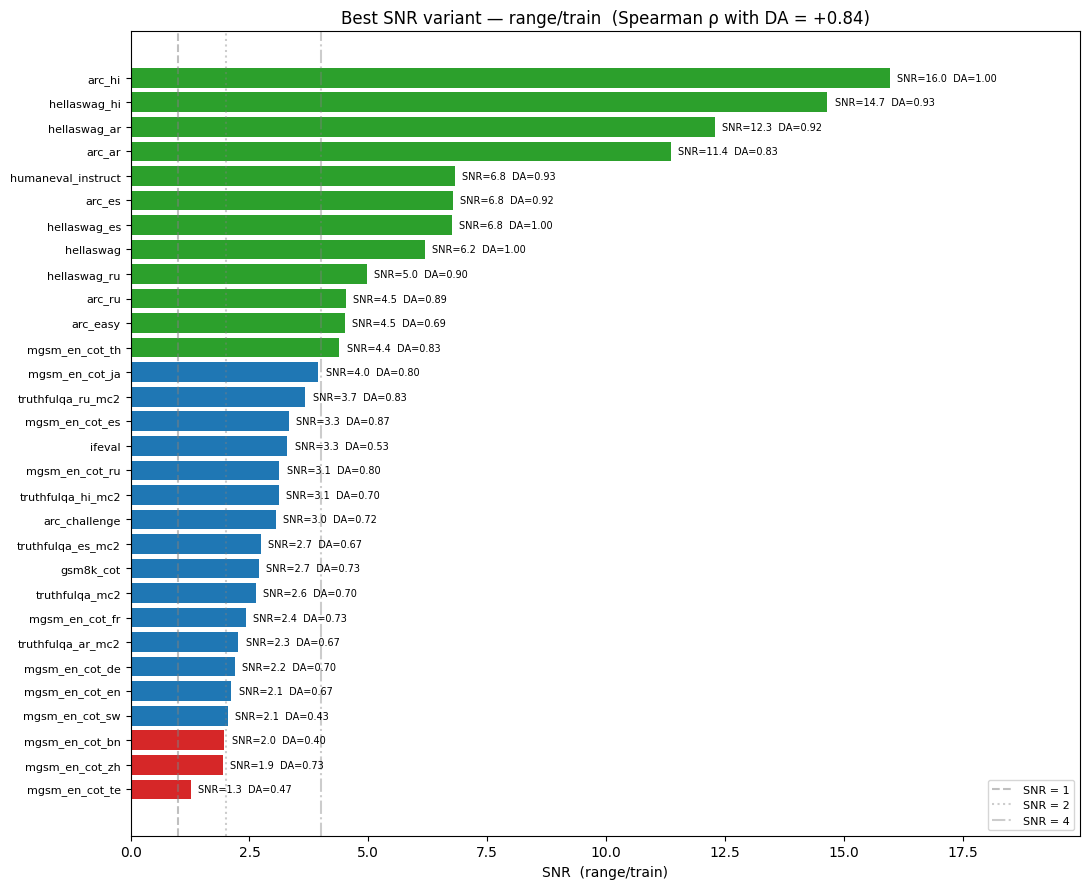

In [14]:
data = [(t, records[t][f"snr_{kind}"][var], records[t]["da"]) for t in task_list]
data.sort(key=lambda x: -x[1])
tasks_s = [d[0] for d in data]; snrs_s = [d[1] for d in data]; das_s = [d[2] for d in data]

fig, ax = plt.subplots(figsize=(11, 9))
colors = ["#2ca02c" if s > 4 else "#1f77b4" if s > 2 else "#d62728" for s in snrs_s]
ax.barh(range(len(tasks_s)), snrs_s, color=colors)
ax.set_yticks(range(len(tasks_s))); ax.set_yticklabels(tasks_s, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(f"SNR  ({best_name})")
ax.set_title(f"Best SNR variant — {best_name}  (Spearman ρ with DA = {best_rho:+.2f})")
for x in [1, 2, 4]:
    ax.axvline(x, color="gray", linestyle="--" if x == 1 else (":" if x == 2 else "-."),
               alpha=0.4 + 0.1 * (x == 1), label=f"SNR = {x}")
for i, (s, da) in enumerate(zip(snrs_s, das_s)):
    ax.text(s + 0.15, i, f"SNR={s:.1f}  DA={da:.2f}", va="center", fontsize=7)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, max(snrs_s) * 1.25); fig.tight_layout(); plt.show()

## 6. Score-trajectory plot — every benchmark, every model, all checkpoints

Visual sanity check that the underlying numbers behave reasonably.

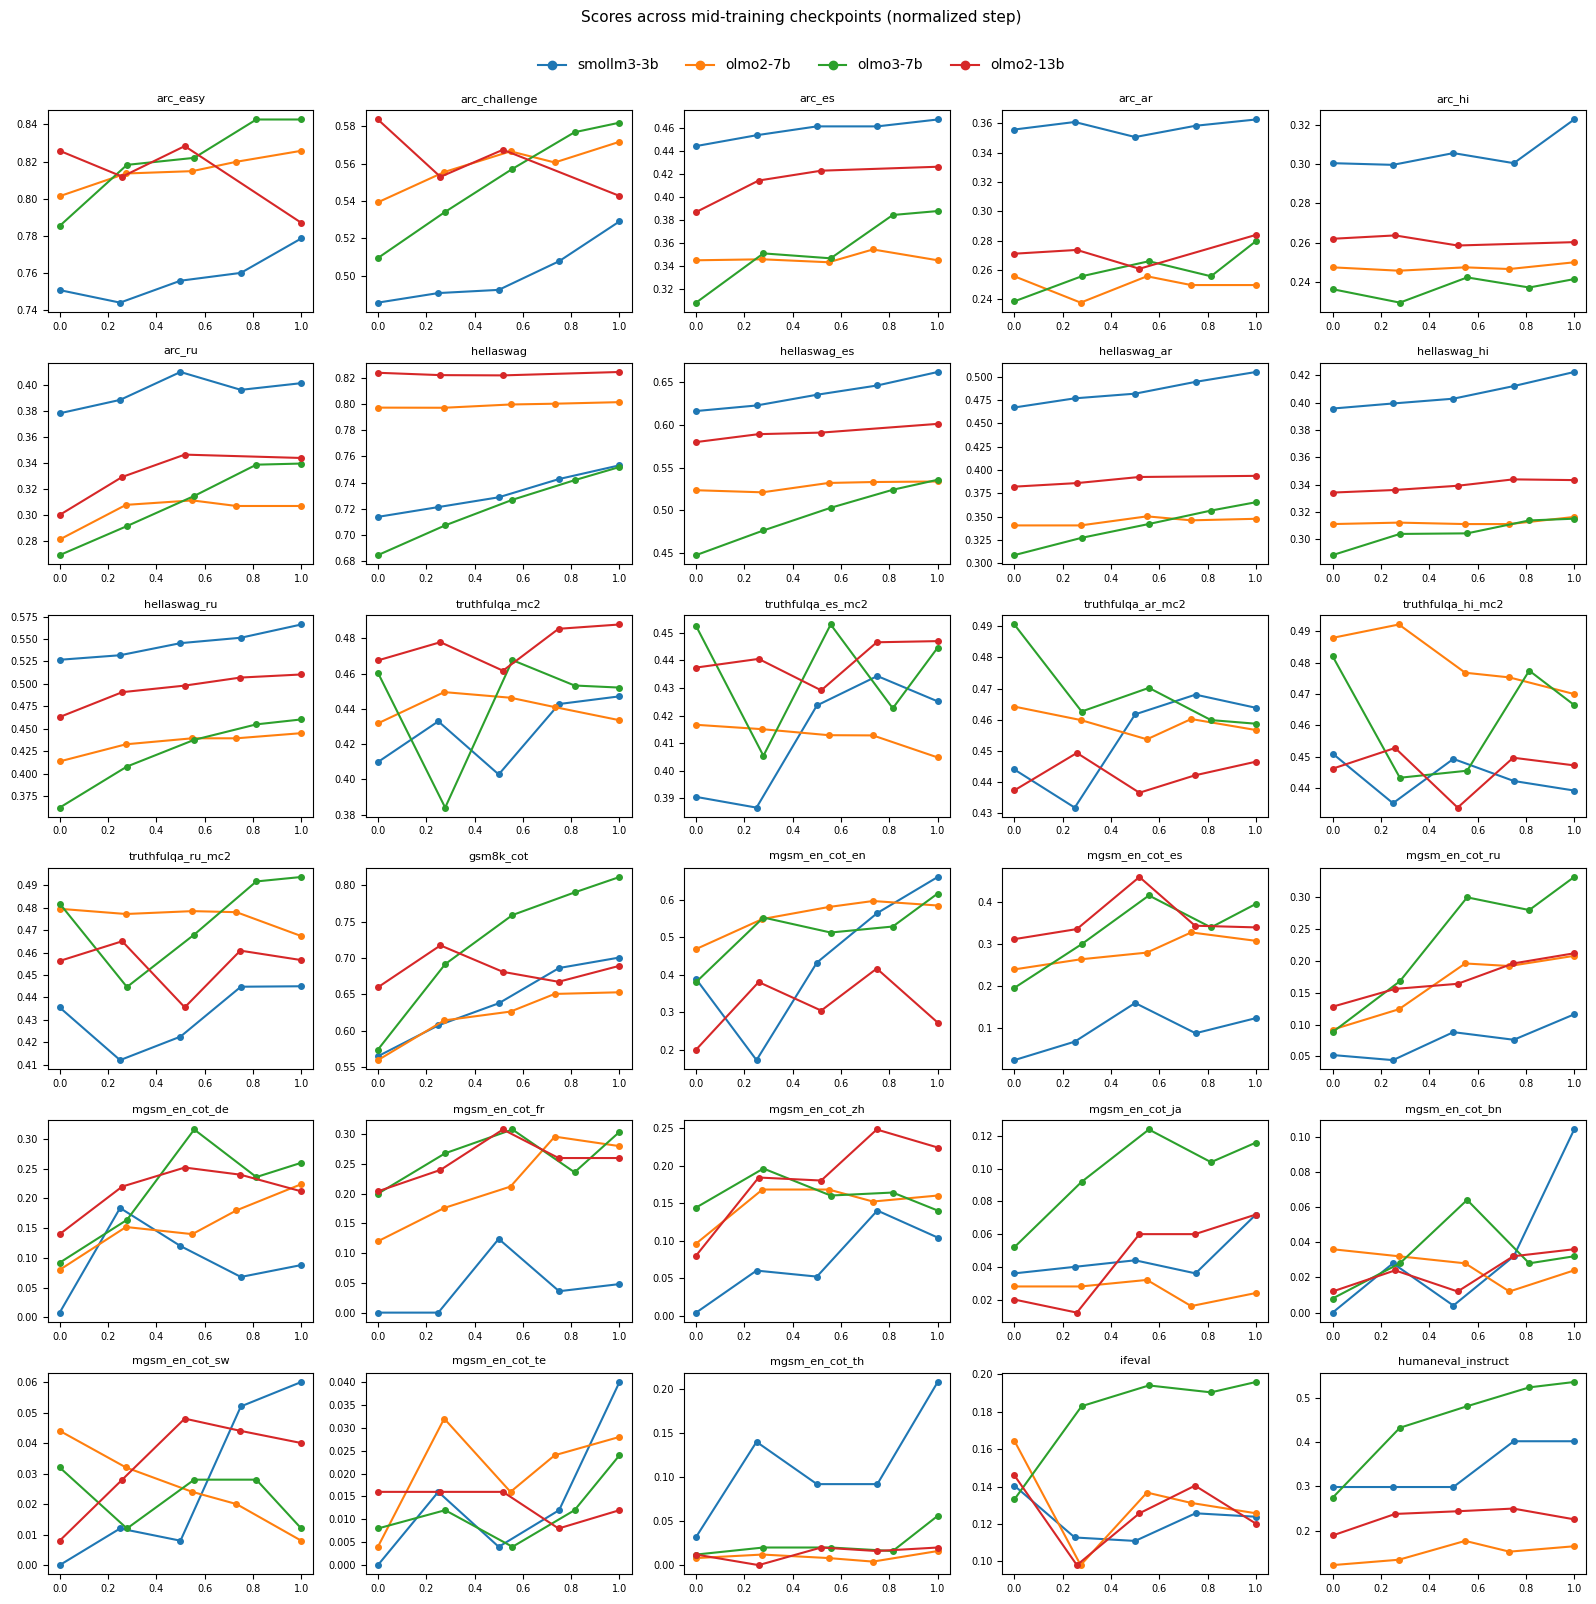

In [15]:
MODEL_COLORS = {"smollm3-3b": "#1f77b4", "olmo2-7b": "#ff7f0e",
                "olmo3-7b":   "#2ca02c", "olmo2-13b": "#d62728"}

cols = 5
rows_n = (len(minimal) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3.2, rows_n * 2.6), squeeze=False)

for i, t in enumerate(minimal):
    ax = axes[i // cols][i % cols]
    for m in models:
        pts = by_task[t][m]
        if not pts: continue
        steps = [p[0] for p in pts]; vals = [p[1] for p in pts]
        s_min, s_max = min(steps), max(steps)
        xs = [(s - s_min) / (s_max - s_min) if s_max > s_min else 0.5 for s in steps]
        ax.plot(xs, vals, "o-", color=MODEL_COLORS[m], label=m, markersize=4, linewidth=1.5)
    ax.set_title(t, fontsize=8); ax.tick_params(labelsize=7)
for j in range(len(minimal), rows_n * cols):
    axes[j // cols][j % cols].axis("off")
handles = [plt.Line2D([0], [0], color=MODEL_COLORS[m], marker="o", label=m) for m in models]
fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 1.002), frameon=False)
fig.suptitle("Scores across mid-training checkpoints (normalized step)", y=1.025, fontsize=11)
fig.tight_layout(); plt.show()

## 7. Full SNR/DA table

In [16]:
print(f"{'task':<25} {'DA':>6} {'SNR':>6}   noise_train  noise_eval")
print("-" * 65)
for t, snr, da in data:
    r = records[t]
    print(f"{t:<25} {da:.3f}  {snr:5.1f}   {r['noise_train']:.4f}      {r['noise_eval']:.4f}")

task                          DA    SNR   noise_train  noise_eval
-----------------------------------------------------------------
arc_hi                    1.000   16.0   0.0171      0.0494
hellaswag_hi              0.933   14.7   0.0203      0.0146
hellaswag_ar              0.917   12.3   0.0310      0.0133
arc_ar                    0.833   11.4   0.0339      0.0469
humaneval_instruct        0.933    6.8   0.1642      0.1324
arc_es                    0.917    6.8   0.0416      0.0369
hellaswag_es              1.000    6.8   0.0318      0.0090
hellaswag                 1.000    6.2   0.0158      0.0055
hellaswag_ru              0.900    5.0   0.0477      0.0109
arc_ru                    0.889    4.5   0.0582      0.0412
arc_easy                  0.694    4.5   0.0200      0.0103
mgsm_en_cot_th            0.833    4.4   0.5955      0.4449
mgsm_en_cot_ja            0.800    4.0   0.3645      0.3119
truthfulqa_ru_mc2         0.833    3.7   0.0279      0.0339
mgsm_en_cot_es            0.

## Conclusions

1. **Best SNR variant for our setup: `range / train_noise`.** Spearman ρ = +0.84 with DA. Validates the Allen AI default empirically.
2. **Most reliable benchmarks (high SNR + high DA):** `arc_hi`, `hellaswag_hi/ar/es/ru/en`, `humaneval_instruct`, `arc_ar/es`. These genuinely distinguish models and rank them consistently.
3. **Unreliable benchmarks (low SNR + low DA):** `mgsm_en_cot_te/bn/sw/zh` — generation issues (the model often outputs an empty string due to a stop-sequence quirk), so scores look like noise.
4. **Methodology insight.** Within-eval bootstrap noise (`noise_eval`) does *not* better predict DA than the simple `noise_train`. DA is fundamentally about checkpoint-to-checkpoint stability of model rankings; that's exactly what `noise_train` measures.